In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)


In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])


In [3]:
target_species = 4.0
rolling = int(target_species)

spec_count_signal = rd.metric("count.species").rolling(rolling).mean() / target_species
spec_dist_signal = (
    rd.metric("species.distance").mean().rolling(rolling).mean() / target_species
)
spec_thresh_signal = rd.metric("species.threshold").rolling(rolling).mean()
spec_evenness_signal = rd.metric("species.evenness").rolling(rolling).mean()

distance_signal = (
    (rd.lit(0.9) * spec_count_signal)
    + (rd.lit(0.4) * spec_dist_signal)
    + (rd.lit(0.2) * spec_thresh_signal)
    + (rd.lit(0.1) * spec_evenness_signal)
).clamp(0.01, 10.0)

distance_signal_mean = distance_signal.mean()
species_count_mean = rd.metric("count.species").mean().rolling(10).mean()

In [4]:
collector = rd.MetricCollector()


engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), distance_signal)
    .metrics(
        distance_signal_mean=distance_signal_mean, species_count_mean=species_count_mean
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)


2026-04-29T22:57:20.631292Z  INFO Epoch 1    | Score:   2.0038 | Time: 729.29µs
2026-04-29T22:57:20.631522Z  INFO Epoch 2    | Score:   2.0038 | Time: 872.71µs
2026-04-29T22:57:20.631735Z  INFO Epoch 3    | Score:   1.6821 | Time: 1.01ms
2026-04-29T22:57:20.631933Z  INFO Epoch 4    | Score:   1.6821 | Time: 1.14ms
2026-04-29T22:57:20.632168Z  INFO Epoch 5    | Score:   1.6821 | Time: 1.31ms
2026-04-29T22:57:20.632409Z  INFO Epoch 6    | Score:   1.6821 | Time: 1.48ms
2026-04-29T22:57:20.632618Z  INFO Epoch 7    | Score:   1.6821 | Time: 1.63ms
2026-04-29T22:57:20.632805Z  INFO Epoch 8    | Score:   1.6821 | Time: 1.76ms
2026-04-29T22:57:20.632981Z  INFO Epoch 9    | Score:   1.6820 | Time: 1.88ms
2026-04-29T22:57:20.633201Z  INFO Epoch 10   | Score:   1.6820 | Time: 2.03ms
2026-04-29T22:57:20.633488Z  INFO Epoch 11   | Score:   1.6820 | Time: 2.24ms
2026-04-29T22:57:20.633724Z  INFO Epoch 12   | Score:   1.6820 | Time: 2.40ms
2026-04-29T22:57:20.633942Z  INFO Epoch 13   | Score:   1.68

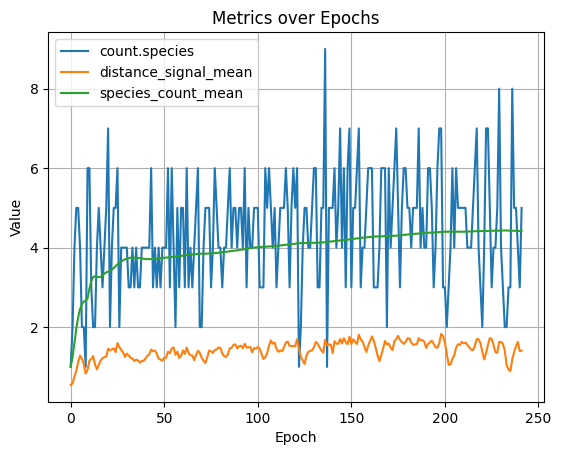

In [5]:
collector.plot(
    # "species.threshold", "count.species", "rate.diversity", "species.evenness"
    "count.species",
    "distance_signal_mean",
    "species_count_mean",
)


In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",1.0,1.0,1.0,0.0,0.0,NaN,1.0,1.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",2.0,3.0,1.5,0.707107,0.5,NaN,1.0,2.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",4.0,7.0,2.333333,1.527525,2.333333,8.049846,1.0,4.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",5.0,12.0,3.0,1.825742,3.333333,4.3260e-7,1.0,5.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",5.0,17.0,3.4,1.81659,3.3,-1.618874,1.0,5.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",5.0,1052.0,4.420168,1.408209,1.983051,0.132344,1.0,9.0,238,null,null,null,null,null,null,237,1,"[""species"", ""statistic""]"
"""count.species""",5.0,1057.0,4.422594,1.405748,1.976126,0.118822,1.0,9.0,239,null,null,null,null,null,null,238,1,"[""species"", ""statistic""]"
"""count.species""",4.0,1061.0,4.420833,1.403069,1.968602,0.130505,1.0,9.0,240,null,null,null,null,null,null,239,1,"[""species"", ""statistic""]"


In [9]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""index""",1.0,1.0,1.0,0.0,0.0,NaN,1.0,1.0,1,null,null,null,null,null,null,0,0,"[""statistic""]"
"""unique.scores""",3.0,3.0,3.0,0.0,0.0,NaN,3.0,3.0,1,null,null,null,null,null,null,0,1,"[""derived"", ""statistic"", ""score""]"
"""mutate.operation""",0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1,null,null,null,null,null,null,0,1,"[""statistic""]"
"""mutate.graph.time""",0.000046,0.000046,0.000046,0.0,0.0,NaN,0.000046,0.000046,1,46µs,46µs,0µs,46µs,46µs,0µs,0,1,"[""time""]"
"""count.evaluation""",8.0,108.0,54.0,65.053825,4232.0,NaN,8.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""age.replace""",2.0,2.0,2.0,0.0,0.0,NaN,2.0,2.0,1,null,null,null,null,null,null,141,1,"[""failure"", ""age"", ""statistic""]"
"""species.distance""",0.477539,145.379639,0.956445,0.653991,0.427704,0.0,0.024546,1.674427,152,null,null,null,null,null,null,241,152,"[""species"", ""distribution""]"
"""size.species""",8.0,100.0,20.0,28.853077,832.5,2.686785,1.0,70.0,5,null,null,null,null,null,null,241,5,"[""species"", ""distribution""]"


In [12]:
print(result.index())
last_version = df.select("version").max().item()
last_version

242


241